In [14]:
#%matplotlib widget

In [15]:
# this code is used to analyse the results of sampling from sampler.ipynb 
# physical properties of the sampled structures are analysed and compared to the full dataset
# e.g. distribution of energies, forces, stresses, structural properties (RDF, ADF, etc.)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob 
from ase.io import iread
from sampling_analysis_utils import *

In [ ]:
path_to_data = ['/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.3.Ts.100.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.300.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.3.Ts.300.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.1.Ts.100.NO.rand.zpe',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.3.Ts.100.NO.rand.zpe',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.1.Ts.300.NO.rand.zpe',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.3.Ts.300.NO.rand.zpe']

if not os.path.isdir(path_to_data):
    raise NotADirectoryError(f"{path_to_data} is not a valid directory.")
else:
    print(f"Directory {path_to_data} exists and is selected.")

vasp_files = []
for p in path_to_data:
    vasp_files.extend(glob.glob(os.path.join(p, "vasprun-*.xml")))

vasp_files = sorted(vasp_files)

if not vasp_files:
    raise FileNotFoundError(f"No vasprun.xml files found in {path_to_data}.")
else:
    print(f"Found {len(vasp_files)} vasprun files across {len(path_to_data)} directories.")

# Read all structures from the VASP files with ASE
full = [atoms for f in vasp_files for atoms in iread(f, index=':')]
print(f"Total number of structures read: {len(full)}")

Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/ exists and is selected.
Found 97 vasprun files.
Total number of structures read: 117881


In [18]:
method_trajs = {
    #"FPS": "selected/2500_01_100/FPS_selected.traj",
    #"BIRCH": "selected/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/BIRCH_selected.traj",
    #"FPS" : "selected/vaspdata.Ei.0.3.Ts.300.NO.rand.zpe/FPS_selected.traj"
    "Random" : "selected/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/Random_selected.traj",
}

#birch  = load_traj(method_trajs["BIRCH"])
#sampl = load_traj(method_trajs["FPS"])
sampl = load_traj(method_trajs["Random"])

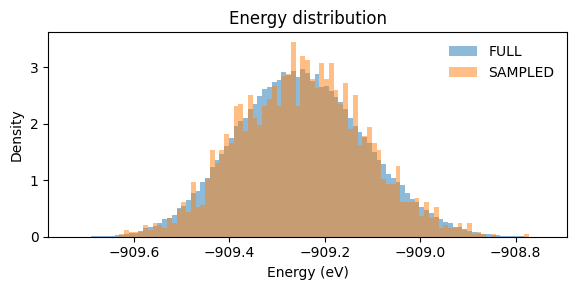

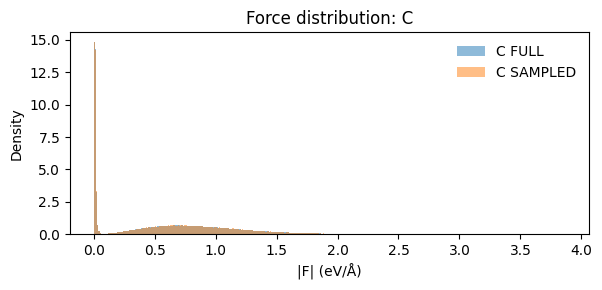

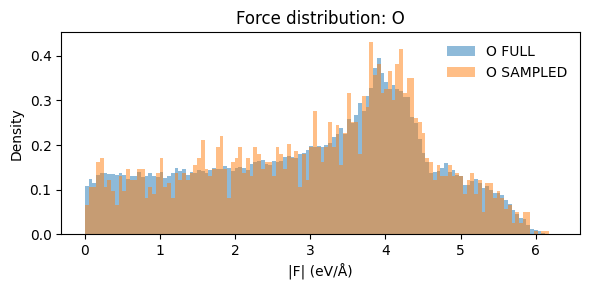

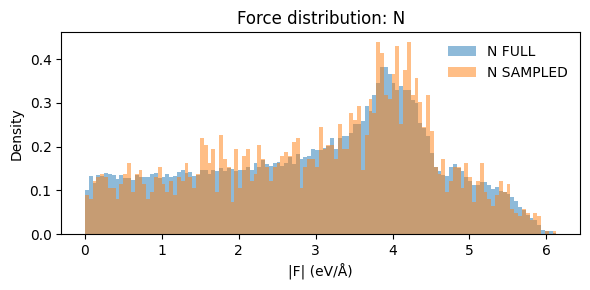

In [19]:
# --- Energies (per structure)
E_full = energies(full)
E_samp = energies(sampl)   # or birch / any other sample

bin_width_en = 0.01  # eV
arr = np.concatenate([E_full[~np.isnan(E_full)], E_samp[~np.isnan(E_samp)]])
lo, hi = arr.min(), arr.max()
n_bins = max(1, int(np.ceil((hi - lo) / bin_width_en)))
edges = np.linspace(lo, hi, n_bins + 1)

plt.figure(figsize=(6,3))
plt.hist(E_full[~np.isnan(E_full)], bins=edges, alpha=0.5, label="FULL", density=True)
plt.hist(E_samp[~np.isnan(E_samp)], bins=edges, alpha=0.5, label="SAMPLED", density=True)
plt.xlabel("Energy (eV)"); plt.ylabel("Density")
plt.title("Energy distribution")
plt.legend(frameon=False); plt.tight_layout(); plt.show()

# --- Forces (per atom, by species)
F_full = force_norms_by_species(full)
F_samp = force_norms_by_species(sampl)

bin_width_f_NO = 0.05  # eV/Å
bin_width_f_C  = 0.01  # eV/Å
for species in set(F_full) | set(F_samp):
    arr = []
    if species in F_full:
        arr.append(F_full[species])
    if species in F_samp:
        arr.append(F_samp[species])
    arr = np.concatenate(arr)
    lo, hi = arr.min(), arr.max()
    n_bins = max(1, int(np.ceil((hi - lo) / (bin_width_f_NO if species == "N" or species == "O" else bin_width_f_C))))
    edges = np.linspace(lo, hi, n_bins + 1)

    plt.figure(figsize=(6,3))
    if species in F_full:
        plt.hist(F_full[species], bins=edges, alpha=0.5, label=f"{species} FULL", density=True)
    if species in F_samp:
        plt.hist(F_samp[species], bins=edges, alpha=0.5, label=f"{species} SAMPLED", density=True)
    plt.xlabel("|F| (eV/Å)"); plt.ylabel("Density")
    plt.title(f"Force distribution: {species}")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()